In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os, glob
import numpy as np
import pandas as pd

ROOT = "/content/drive/MyDrive/3.ML Project MBUST/dataset"
OUT_DIR = os.path.join(ROOT, "results")
os.makedirs(OUT_DIR, exist_ok=True)

CAP_PER_CLASS = 2000
RANDOM_STATE = 42
TARGET_CLASSES = ["Benign", "DDoS", "DoS", "MQTT", "Recon", "Spoofing"]


def class_from_name(fname: str) -> str:
    s = fname.lower()
    if "benign" in s:
        return "Benign"
    if "arp" in s or "spoof" in s:
        return "Spoofing"
    if "recon" in s:
        return "Recon"
    if "mqtt" in s:
        return "MQTT"
    if "ddos" in s:
        return "DDoS"
    if "dos" in s:
        return "DoS"
    return "Unknown"


def list_attack_csvs(root=ROOT):
    skip_prefixes = ("file_inventory", "ciciomt2024_", "sampling_log")
    files = []
    for fp in glob.glob(os.path.join(root, "**", "*.csv"), recursive=True):
        if os.path.basename(os.path.dirname(fp)).lower() == "results":
            continue
        if os.path.basename(fp).startswith(skip_prefixes):
            continue
        files.append(fp)
    return sorted(files)


FILES = list_attack_csvs()
print("ROOT :", ROOT)
print("OUT  :", OUT_DIR)
print("Files:", len(FILES))
for fp in FILES:
    print(" ", class_from_name(os.path.basename(fp)), os.path.basename(fp))

ROOT : /content/drive/MyDrive/3.ML Project MBUST/dataset
OUT  : /content/drive/MyDrive/3.ML Project MBUST/dataset/results
Files: 19
  Benign Benign_train.pcap.csv
  DDoS TCP_IP-DDoS-ICMP1_train.pcap.csv
  DDoS TCP_IP-DDoS-SYN1_train.pcap.csv
  DDoS TCP_IP-DDoS-TCP1_train.pcap.csv
  DDoS TCP_IP-DDoS-UDP1_train.pcap.csv
  DoS TCP_IP-DoS-ICMP1_train.pcap.csv
  DoS TCP_IP-DoS-SYN1_train.pcap.csv
  DoS TCP_IP-DoS-TCP1_train.pcap.csv
  DoS TCP_IP-DoS-UDP1_train.pcap.csv
  MQTT MQTT-DDoS-Connect_Flood_train.pcap.csv
  MQTT MQTT-DDoS-Publish_Flood_train.pcap.csv
  MQTT MQTT-DoS-Connect_Flood_train.pcap.csv
  MQTT MQTT-DoS-Publish_Flood_train.pcap.csv
  MQTT MQTT-Malformed_Data_train.pcap.csv
  Recon Recon-OS_Scan_train.pcap.csv
  Recon Recon-Ping_Sweep_train.pcap.csv
  Recon Recon-Port_Scan_train.pcap.csv
  Recon Recon-VulScan_train.pcap.csv
  Spoofing ARP_Spoofing_train.pcap.csv


In [9]:
print("ROOT", ROOT)
print("n FILES", len(FILES))
print(FILES[:5])

ROOT /content/drive/MyDrive/3.ML Project MBUST/dataset
n FILES 19
['/content/drive/MyDrive/3.ML Project MBUST/dataset/benign/Benign_train.pcap.csv', '/content/drive/MyDrive/3.ML Project MBUST/dataset/ddos/TCP_IP-DDoS-ICMP1_train.pcap.csv', '/content/drive/MyDrive/3.ML Project MBUST/dataset/ddos/TCP_IP-DDoS-SYN1_train.pcap.csv', '/content/drive/MyDrive/3.ML Project MBUST/dataset/ddos/TCP_IP-DDoS-TCP1_train.pcap.csv', '/content/drive/MyDrive/3.ML Project MBUST/dataset/ddos/TCP_IP-DDoS-UDP1_train.pcap.csv']


## 1. Dataset inventory and schema check

This section inspects the official CICIoMT2024 Wi-Fi/MQTT **attack** CSVs that were uploaded to Drive.

Each file is one attack shard from the authors' train split (filename encodes the attack). We do **not** model on the raw shards. The goals here are only to:

- list every CSV and assign it to one of the six target classes  
  `{Benign, DDoS, DoS, Recon, MQTT, Spoofing}`;
- record rows, columns, and missing-value counts per file;
- verify that all files share the same feature width (column consistency);
- write a reproducible inventory table to `dataset/results/file_inventory.csv`.

Profiling captures and Bluetooth traces are excluded. Stratified sampling , data analysis, visualization and model training start in the next section, after this inventory is acceptable.

In [10]:
# Section 1 — inventory (guarded)
assert "FILES" in globals(), "Run Cell 0 first."
print("FILES found:", len(FILES))
if not FILES:
    raise FileNotFoundError(
        "Cell 0 found no attack CSVs. Check ROOT and print(os.listdir(ROOT))."
    )

records = []
for fp in FILES:
    raw = pd.read_csv(fp, low_memory=False)
    raw.columns = [c.strip() for c in raw.columns]
    n_rows, n_cols = raw.shape
    n_missing = int(raw.isna().sum().sum())
    n_cells = n_rows * n_cols
    rec = {
        "class": class_from_name(os.path.basename(fp)),
        "file": os.path.basename(fp),
        "n_rows": int(n_rows),
        "n_cols": int(n_cols),
        "n_missing_cells": n_missing,
        "missing_pct": round(100.0 * n_missing / n_cells, 4) if n_cells else 0.0,
        "has_missing": bool(n_missing > 0),
    }
    records.append(rec)
    print(f"{rec['class']:10s} {rec['file']:45s} "
          f"{rec['n_rows']:8d} x {rec['n_cols']:3d}  missing={n_missing}")

inventory = pd.DataFrame.from_records(records)
print("inventory columns:", list(inventory.columns))
print("inventory shape   :", inventory.shape)

if inventory.empty or "n_cols" not in inventory.columns:
    raise RuntimeError("Inventory is empty. FILES were found but no tables were read.")

mode_cols = int(inventory["n_cols"].mode().iloc[0])
inventory["cols_consistent"] = inventory["n_cols"].eq(mode_cols)
inventory = (
    inventory[[
        "class", "file", "n_rows", "n_cols", "cols_consistent",
        "n_missing_cells", "missing_pct", "has_missing"
    ]]
    .sort_values(["class", "file"])
    .reset_index(drop=True)
)

inv_path = os.path.join(OUT_DIR, "file_inventory.csv")
inventory.to_csv(inv_path, index=False)

print("\nSaved:", inv_path)
print("Files:", len(inventory),
      "| classes:", inventory["class"].nunique(),
      "| schema OK:", bool(inventory["cols_consistent"].all()),
      "| n_cols:", mode_cols)
print("\nRows per class (full shards):")
print(inventory.groupby("class")["n_rows"].sum())

FILES found: 19
Benign     Benign_train.pcap.csv                           192732 x  45  missing=0
DDoS       TCP_IP-DDoS-ICMP1_train.pcap.csv                194938 x  45  missing=0
DDoS       TCP_IP-DDoS-SYN1_train.pcap.csv                 199390 x  45  missing=0
DDoS       TCP_IP-DDoS-TCP1_train.pcap.csv                 202311 x  45  missing=0
DDoS       TCP_IP-DDoS-UDP1_train.pcap.csv                 206170 x  45  missing=0
DoS        TCP_IP-DoS-ICMP1_train.pcap.csv                 104507 x  45  missing=0
DoS        TCP_IP-DoS-SYN1_train.pcap.csv                  111431 x  45  missing=0
DoS        TCP_IP-DoS-TCP1_train.pcap.csv                   95407 x  45  missing=0
DoS        TCP_IP-DoS-UDP1_train.pcap.csv                  137011 x  45  missing=0
MQTT       MQTT-DDoS-Connect_Flood_train.pcap.csv          173036 x  45  missing=0
MQTT       MQTT-DDoS-Publish_Flood_train.pcap.csv           27623 x  45  missing=0
MQTT       MQTT-DoS-Connect_Flood_train.pcap.csv            12773 x  45

,class,file,n_rows,n_cols,cols_consistent,n_missing_cells,missing_pct,has_missing
0,Benign,Benign_train.pcap.csv,192732,45,True,0,0.0,False
1,DDoS,TCP_IP-DDoS-ICMP1_train.pcap.csv,194938,45,True,0,0.0,False
2,DDoS,TCP_IP-DDoS-SYN1_train.pcap.csv,199390,45,True,0,0.0,False
3,DDoS,TCP_IP-DDoS-TCP1_train.pcap.csv,202311,45,True,0,0.0,False
4,DDoS,TCP_IP-DDoS-UDP1_train.pcap.csv,206170,45,True,0,0.0,False
5,DoS,TCP_IP-DoS-ICMP1_train.pcap.csv,104507,45,True,0,0.0,False
6,DoS,TCP_IP-DoS-SYN1_train.pcap.csv,111431,45,True,0,0.0,False
7,DoS,TCP_IP-DoS-TCP1_train.pcap.csv,95407,45,True,0,0.0,False
8,DoS,TCP_IP-DoS-UDP1_train.pcap.csv,137011,45,True,0,0.0,False
9,MQTT,MQTT-DDoS-Connect_Flood_train.pcap.csv,173036,45,True,0,0.0,False


## 2. Stratified working sample

Build a working table of at most 2,000 rows per class from the files listed in Section 1.

- One-file classes (Benign, Spoofing): draw the whole budget from that file.
- Multi-file classes (DDoS, DoS, MQTT, Recon): split the budget equally across shards, then fill any shortfall from leftover rows.

Save `results/ciciomt2024_6class_12k.csv` and `results/sampling_log.csv`. Later sections use only the 12k file.

In [11]:
assert "FILES" in globals(), "Run Cell 0 first."

by_class = {}
for fp in FILES:
    by_class.setdefault(class_from_name(os.path.basename(fp)), []).append(fp)


def sample_class(label, paths, cap=CAP_PER_CLASS, seed=RANDOM_STATE):
    quota = cap // len(paths)
    parts, leftover = [], []

    for i, fp in enumerate(paths):
        raw = pd.read_csv(fp, low_memory=False)
        raw.columns = [c.strip() for c in raw.columns]
        raw["source_file"] = os.path.basename(fp)
        n = min(quota, len(raw))
        take = raw.sample(n=n, random_state=seed + i)
        take["label"] = label
        parts.append(take)
        leftover.append(raw.drop(take.index))

    sample = pd.concat(parts, ignore_index=True)
    shortfall = cap - len(sample)
    if shortfall > 0:
        pool = pd.concat(leftover, ignore_index=True)
        extra_n = min(shortfall, len(pool))
        if extra_n:
            extra = pool.sample(n=extra_n, random_state=seed + 99)
            extra["label"] = label
            sample = pd.concat([sample, extra], ignore_index=True)
    return sample


samples, log_rows = [], []
for label in TARGET_CLASSES:
    paths = by_class.get(label, [])
    if not paths:
        print("MISSING CLASS:", label)
        continue
    part = sample_class(label, paths)
    samples.append(part)
    print(f"{label:10s} files={len(paths):2d}  sampled={len(part)}")
    for fn, n in part["source_file"].value_counts().items():
        log_rows.append({"class": label, "file": fn, "n_sampled": int(n)})

df = (
    pd.concat(samples, ignore_index=True)
      .sample(frac=1.0, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)

meta = ["label", "source_file"]
feature_cols = [c for c in df.columns if c not in meta]
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

out = os.path.join(OUT_DIR, "ciciomt2024_6class_12k.csv")
log_out = os.path.join(OUT_DIR, "sampling_log.csv")
df.to_csv(out, index=False)
pd.DataFrame(log_rows).to_csv(log_out, index=False)

print("\nWorking set:", df.shape)
print(df["label"].value_counts().reindex(TARGET_CLASSES))
print("Saved:", out)
print("Log   :", log_out)
df.head()

Benign     files= 1  sampled=2000
DDoS       files= 4  sampled=2000
DoS        files= 4  sampled=2000
MQTT       files= 5  sampled=2000
Recon      files= 4  sampled=2000
Spoofing   files= 1  sampled=2000

Working set: (12000, 47)
label
Benign      2000
DDoS        2000
DoS         2000
MQTT        2000
Recon       2000
Spoofing    2000
Name: count, dtype: int64
Saved: /content/drive/MyDrive/3.ML Project MBUST/dataset/results/ciciomt2024_6class_12k.csv
Log   : /content/drive/MyDrive/3.ML Project MBUST/dataset/results/sampling_log.csv


,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,source_file,label
0,99354.60,6.0,64.0,0.614031,0.614031,0.0,0.00,0.00,0.00,0.50,...,67.00,7.295609e-06,5.5,11.550724,1.110011,0.770502,0.80,38.50,Benign_train.pcap.csv,Benign
1,1676.46,6.0,64.0,17.355759,17.355759,0.0,0.01,0.01,0.21,0.53,...,264.75,8.466697e+07,9.5,22.931848,439.139624,136609.753609,0.88,141.55,MQTT-DDoS-Publish_Flood_train.pcap.csv,MQTT
2,4916323.00,6.0,56.0,7217.947981,7217.947981,0.0,0.00,0.00,0.00,0.10,...,1514.00,1.694694e+08,13.5,55.027266,0.000000,0.000000,0.00,244.60,Benign_train.pcap.csv,Benign
3,112.00,6.0,51.0,6.837609,6.837609,0.0,0.00,1.00,0.00,0.00,...,58.00,9.608269e-06,5.5,10.770330,0.000000,0.000000,0.00,38.50,Recon-Port_Scan_train.pcap.csv,Recon
4,121068.90,6.0,61.5,29.738698,29.738698,0.0,0.00,0.00,0.00,0.60,...,97.00,1.694676e+08,13.5,26.429392,714.313658,256318.989054,1.00,244.60,Benign_train.pcap.csv,Benign


## 3. Exploratory data analysis

All analysis uses only the stratified working table
`results/ciciomt2024_6class_12k.csv`.

We check class balance after sampling, missing and non-finite values,
constant or near-constant features, pairwise correlation among numeric
predictors, and class-conditional structure on a small set of flow
features (rate, protocol, TCP flags, inter-arrival time). A 2-D PCA
plot is used only as a qualitative view of separability, not as a model.

In [13]:
# Section 3 — EDA on the working sample
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "OUT_DIR" in globals(), "Run Cell 0 first."

sample_path = os.path.join(OUT_DIR, "ciciomt2024_6class_12k.csv")
log_path = os.path.join(OUT_DIR, "sampling_log.csv")

df = pd.read_csv(sample_path)
meta = [c for c in ("label", "source_file") if c in df.columns]
X = df.drop(columns=meta)
y = df["label"]

print("Working table:", df.shape)
print("Features     :", X.shape[1])
print(y.value_counts().reindex(TARGET_CLASSES))

Working table: (12000, 47)
Features     : 45
label
Benign      2000
DDoS        2000
DoS         2000
MQTT        2000
Recon       2000
Spoofing    2000
Name: count, dtype: int64


In [14]:
# --- quality ---
n_missing = int(X.isna().sum().sum())
n_inf = int(np.isinf(X.select_dtypes(include=[np.number])).sum().sum())
n_dup = int(df.duplicated().sum())
nunique = X.nunique(dropna=False)
const_cols = nunique[nunique <= 1].index.tolist()
near_const = nunique[nunique <= 2].index.tolist()

qa = pd.DataFrame({
    "metric": ["rows", "features", "missing_cells", "inf_cells",
               "duplicate_rows", "constant_features"],
    "value": [len(df), X.shape[1], n_missing, n_inf, n_dup, len(const_cols)],
})
display(qa)
if const_cols:
    print("Constant:", const_cols)

,metric,value
0,rows,12000
1,features,45
2,missing_cells,0
3,inf_cells,0
4,duplicate_rows,11
5,constant_features,2


Constant: ['Drate', 'DHCP']


### 3.1 Cleaning justified by the quality audit

**Duplicate rows.** Repeated identical feature vectors do not add information for LR, k-NN, DT or SVM. They overweight a single flow in accuracy and in nearest-neighbour votes. We drop exact duplicates and keep the first occurrence.

**Constant features.** A column with one unique value has zero variance, so it cannot separate classes and it breaks correlation / PCA / standard scaling. Such columns are removed from the working matrix.

Near-constant columns (two unique values) are **reported but retained** until the feature-subset experiment; some binary protocol flags are legitimately almost constant and still useful.

In [15]:
# 3.1 remove exact duplicates and constant features
n_before = len(df)
feat_before = [c for c in df.columns if c not in ("label", "source_file")]

dup_mask = df.duplicated()
n_dup = int(dup_mask.sum())
df = df.loc[~dup_mask].reset_index(drop=True)

X = df.drop(columns=[c for c in ("label", "source_file") if c in df.columns])
nunique = X.nunique(dropna=False)
const_cols = nunique[nunique <= 1].index.tolist()
near_const = nunique[(nunique > 1) & (nunique <= 2)].index.tolist()

df = df.drop(columns=const_cols)
X = df.drop(columns=[c for c in ("label", "source_file") if c in df.columns])
y = df["label"]

clean_path = os.path.join(OUT_DIR, "ciciomt2024_6class_clean.csv")
df.to_csv(clean_path, index=False)

audit = pd.DataFrame({
    "item": [
        "rows before",
        "exact duplicate rows dropped",
        "rows after",
        "features before",
        "constant features dropped",
        "features after",
        "near-constant features kept",
    ],
    "value": [
        n_before,
        n_dup,
        len(df),
        len(feat_before),
        len(const_cols),
        X.shape[1],
        len(near_const),
    ],
})
display(audit)
print("Dropped constants:", const_cols if const_cols else "none")
print("Near-constant kept:", near_const if near_const else "none")
print("Saved:", clean_path)
print(y.value_counts().reindex(TARGET_CLASSES))

,item,value
0,rows before,12000
1,exact duplicate rows dropped,11
2,rows after,11989
3,features before,45
4,constant features dropped,2
5,features after,43
6,near-constant features kept,3


Dropped constants: ['Drate', 'DHCP']
Near-constant kept: ['ece_flag_number', 'cwr_flag_number', 'IGMP']
Saved: /content/drive/MyDrive/3.ML Project MBUST/dataset/results/ciciomt2024_6class_clean.csv
label
Benign      2000
DDoS        2000
DoS         2000
MQTT        2000
Recon       1989
Spoofing    2000
Name: count, dtype: int64


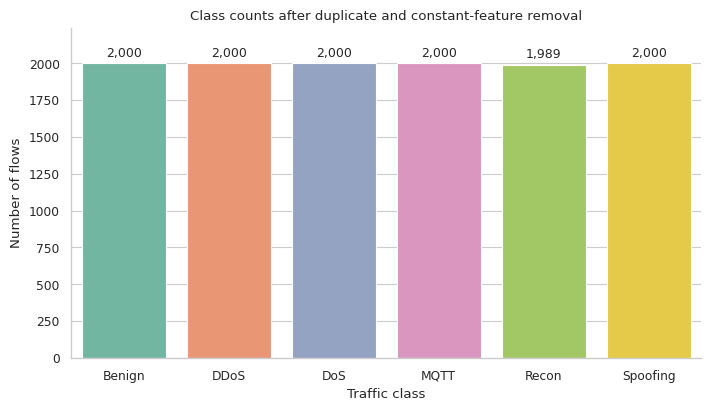

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="paper")

counts = (
    y.value_counts()
     .reindex(TARGET_CLASSES)
     .rename_axis("class")
     .reset_index(name="n")
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
sns.barplot(
    data=counts,
    x="class",
    y="n",
    hue="class",
    palette="Set2",
    legend=False,
    ax=ax,
)
ax.set_title("Class counts after duplicate and constant-feature removal")
ax.set_xlabel("Traffic class")
ax.set_ylabel("Number of flows")
ax.set_ylim(0, counts["n"].max() * 1.12)

for p, n in zip(ax.patches, counts["n"]):
    ax.annotate(
        f"{int(n):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=9, xytext=(0, 3),
        textcoords="offset points",
    )

sns.despine()
plt.tight_layout()
plt.show()

**Figure. Class distribution after cleaning.**
Each bar is one of the six target labels used in this study. Height is the number of **flows** retained for that label after exact-duplicate removal and deletion of constant features.

A *flow* is one row of the CICIoMT2024 CSV: CIC aggregated a short window of packets (10 or 100 packets, depending on the attack) into 45 numeric statistics (rates, flags, protocol indicators, inter-arrival times, size moments). The classifier sees a flow, not a raw packet or a whole session.

*Traffic class* is the 6-class target `y`:

| Class | Meaning in this dataset |
|---|---|
| Benign | Ordinary Wi-Fi / MQTT device traffic |
| DDoS | Distributed floods (SYN, TCP, UDP, ICMP) |
| DoS | Single-source floods of the same families |
| MQTT | MQTT-specific abuse (connect / publish flood, malformed data) |
| Recon | Scanning (port, OS, vulnerability, ping sweep) |
| Spoofing | ARP spoofing |

Sampling was capped at 2,000 flows per class, so the bars should be nearly equal. Any bar slightly below 2,000 is expected: that class had fewer usable rows after de-duplication, or a rare subtype (e.g. ping sweep) could not fill its quota. The plot is a check that cleaning did not collapse a class, not a claim about the original CIC class prior.

,class,shard,n_sampled
0,Benign,Benign,2000
1,DDoS,DDoS-ICMP1,500
2,DDoS,DDoS-SYN1,500
3,DDoS,DDoS-TCP1,500
4,DDoS,DDoS-UDP1,500
5,DoS,DoS-ICMP1,500
6,DoS,DoS-SYN1,500
7,DoS,DoS-TCP1,500
8,DoS,DoS-UDP1,500
9,MQTT,MQTT-DDoS-Connect_Flood,400


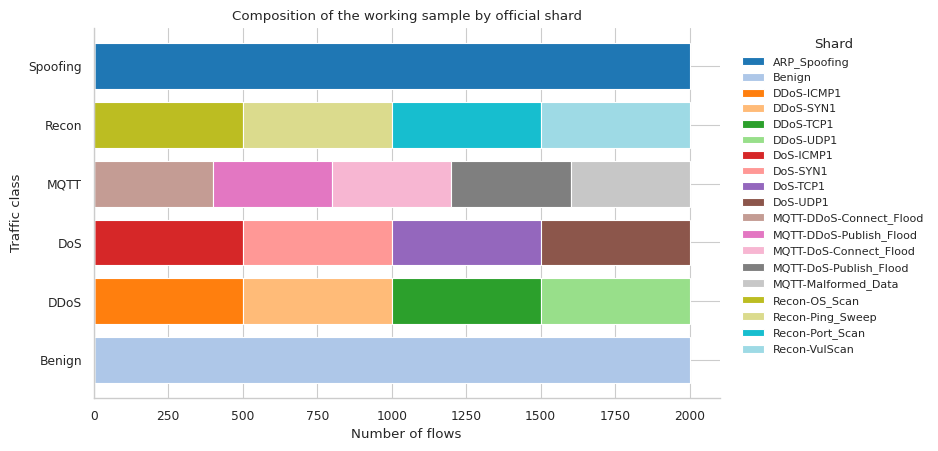

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

def short_shard(name: str) -> str:
    s = name.replace("_train.pcap.csv", "").replace(".pcap.csv", "").replace(".csv", "")
    s = s.replace("TCP_IP-", "")
    return s

if not os.path.exists(log_path):
    print("No sampling_log.csv — run Section 2 first.")
else:
    slog = pd.read_csv(log_path)
    slog["shard"] = slog["file"].map(short_shard)
    display(slog[["class", "shard", "n_sampled"]])

    pivot = (
        slog.pivot_table(index="class", columns="shard",
                         values="n_sampled", aggfunc="sum")
            .reindex(TARGET_CLASSES)
            .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    pivot.plot(
        kind="barh",
        stacked=True,
        width=0.78,
        colormap="tab20",
        ax=ax,
    )
    ax.set_title("Composition of the working sample by official shard")
    ax.set_xlabel("Number of flows")
    ax.set_ylabel("Traffic class")
    ax.legend(
        title="Shard",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=8,
    )
    ax.set_xlim(0, pivot.sum(axis=1).max() * 1.05)
    sns.despine()
    plt.tight_layout()
    plt.show()

**Figure. Subtype mix inside each class.**
Each horizontal bar is one target class. Segments are the official CIC train shards from which those flows were drawn. Benign and Spoofing have a single shard, so they appear as one block. DDoS, DoS, MQTT and Recon are mixtures: the equal-quota rule keeps SYN/TCP/UDP/ICMP floods and the four reconnaissance scans in the sample instead of letting the largest file dominate. Segment heights that fall short of the per-file quota (ping sweep, some MQTT files) are limited by how many rows that shard actually contained.

Least variable features (often flags or rare protocols)


,nunique,missing,mean,std,cv,min,median,max
cwr_flag_number,2,0,0.0000,0.0018,54.7403,0.0,0.0,0.10
IGMP,2,0,0.0000,0.0018,109.4943,0.0,0.0,0.20
ece_flag_number,2,0,0.0001,0.0024,41.3746,0.0,0.0,0.10
Telnet,3,0,0.0001,0.0030,32.4396,0.0,0.0,0.10
SSH,3,0,0.0001,0.0030,32.4396,0.0,0.0,0.10
IRC,3,0,0.0001,0.0038,26.2450,0.0,0.0,0.10
SMTP,3,0,0.0002,0.0040,24.8521,0.0,0.0,0.10
DNS,7,0,0.0019,0.0189,10.0848,0.0,0.0,0.40
fin_flag_number,51,0,0.0113,0.0463,4.1033,0.0,0.0,0.81
HTTP,12,0,0.0041,0.0595,14.4156,0.0,0.0,1.00


Most variable features (scale differs by orders of magnitude)


,nunique,missing,mean,std,cv,min,median,max
IAT,11718,0,8.446241e+07,6.185302e+07,0.7323,0.0,8.467527e+07,1.694694e+08
Header_Length,8517,0,5.970714e+05,1.582031e+06,2.6497,0.0,8.030600e+03,9.861739e+06
Covariance,6667,0,2.785605e+04,7.389056e+04,2.6526,0.0,3.201990e+01,4.920972e+05
Rate,11374,0,3.937802e+03,1.936793e+04,4.9185,0.0,2.891560e+01,4.122312e+05
Srate,11374,0,3.937802e+03,1.936793e+04,4.9185,0.0,2.891560e+01,4.122312e+05
Tot sum,6093,0,2.107381e+03,3.966233e+03,1.8821,249.0,6.358900e+02,2.346700e+04
rst_count,4732,0,6.675544e+02,1.601116e+03,2.3985,0.0,1.000000e+00,9.518500e+03
Max,3496,0,3.185015e+02,4.530791e+02,1.4225,42.0,7.800000e+01,1.514000e+03
AVG,6890,0,2.000167e+02,3.369703e+02,1.6847,42.0,6.733010e+01,1.514000e+03
Tot size,3466,0,2.003284e+02,3.359656e+02,1.6771,42.0,6.700000e+01,1.514000e+03


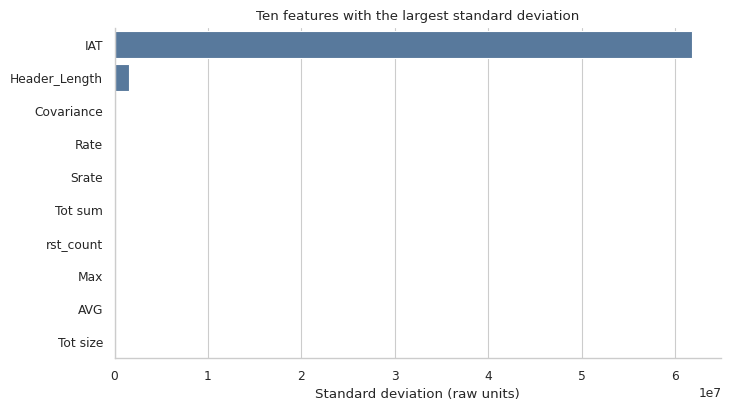

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

nunique = X.nunique(dropna=False)
summary = X.describe().T
summary["missing"] = X.isna().sum()
summary["nunique"] = nunique
summary["cv"] = summary["std"] / summary["mean"].replace(0, np.nan).abs()

summary = summary.rename(columns={
    "50%": "median",
    "25%": "q1",
    "75%": "q3",
})
show_cols = ["nunique", "missing", "mean", "std", "cv", "min", "median", "max"]
summary = summary[show_cols].sort_values("std")

low_var = summary.head(10).round(4)
high_var = summary.sort_values("std", ascending=False).head(10).round(4)

print("Least variable features (often flags or rare protocols)")
display(low_var)

print("Most variable features (scale differs by orders of magnitude)")
display(high_var)

top = high_var.reset_index().rename(columns={"index": "feature"})
fig, ax = plt.subplots(figsize=(7.4, 4.2))
sns.barplot(data=top, y="feature", x="std", color="#4C78A8", ax=ax)
ax.set_title("Ten features with the largest standard deviation")
ax.set_xlabel("Standard deviation (raw units)")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

**Table / figure. Univariate feature summary.**
`nunique` is the number of distinct values; `missing` is the number of NaNs after the earlier `inf → NaN` coercion. `cv` is the coefficient of variation (`std / |mean|`).

Low-variance columns are typically binary protocol or flag indicators that are almost always 0 or 1. They are not constant, so they stay in the matrix. High-variance columns (`Header_Length`, rates, inter-arrival time, magnitude) live on very different raw scales. That is why later models that use distance or linear decision surfaces (k-NN, SVM, logistic regression) must be trained with **feature scaling inside the cross-validation pipe**, not on the raw table.

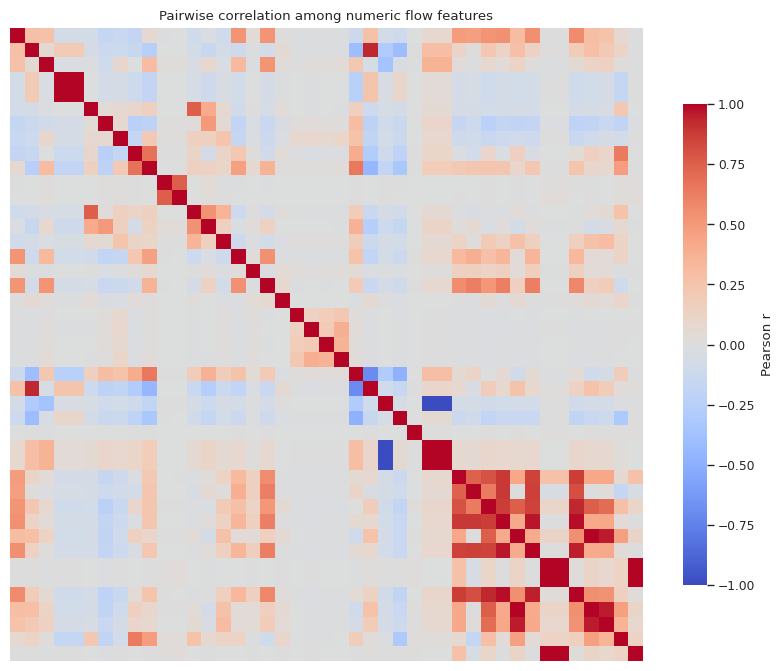

Pairs with |r| ≥ 0.90: 15


,feat_a,feat_b,r
0,ARP,IPv,-1.000
1,ARP,LLC,-1.000
2,Rate,Srate,1.000
3,IPv,LLC,1.000
4,Number,Weight,1.000
5,Std,Radius,1.000
6,IAT,Weight,0.998
7,IAT,Number,0.998
8,AVG,Magnitue,0.983
9,AVG,Tot size,0.966


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

num = X.select_dtypes(include=[np.number])
corr = num.corr()

fig, ax = plt.subplots(figsize=(8.2, 7.0))
sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap="coolwarm",
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={"shrink": 0.72, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Pairwise correlation among numeric flow features")
plt.tight_layout()
plt.show()

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("r")
        .reset_index()
        .rename(columns={"level_0": "feat_a", "level_1": "feat_b"})
)
hi = (
    pairs.loc[pairs["r"].abs() >= 0.90]
         .assign(abs_r=lambda d: d["r"].abs())
         .sort_values("abs_r", ascending=False)
         .drop(columns="abs_r")
         .reset_index(drop=True)
)
print(f"Pairs with |r| ≥ 0.90: {len(hi)}")
display(hi.head(20).round(3))

**Figure. Feature correlation.**
Each cell is Pearson’s *r* between two numeric flow statistics on the cleaned working sample. Axis labels are omitted because 45 names are not readable at this size; the colour bar is the result.

The table lists pairs with `|r| ≥ 0.90`. Rate-family features, flag counts and some size moments are near-duplicates of one another. That redundancy is the rationale for the later comparative study: full feature set versus a reduced subset (mutual information, *k* = 15). We do not drop correlated columns by hand here; the subset experiment does that under a fixed rule.

### 3.5 Mutual information with the 6-class label

Mutual information $I(X_j; Y)$ measures how much knowing feature $j$ reduces uncertainty about the traffic class. Unlike Pearson correlation, it does not assume a linear relationship, which matters for binary flags and heavy-tailed rates.

This cell ranks features on the *full working sample* so we can see which CIC statistics carry class signal. The ranking is descriptive. In the modelling section the top-$k$ subset ($k=15$) is reselected on each training fold only.

,feature,MI,rank,selected_k15
0,IAT,1.4760,1,True
1,Tot sum,0.9443,2,True
2,Tot size,0.9269,3,True
3,Max,0.8941,4,True
4,Magnitue,0.8610,5,True
5,AVG,0.8566,6,True
6,Min,0.8434,7,True
7,Srate,0.7501,8,True
8,Rate,0.7496,9,True
9,rst_count,0.7408,10,True


Saved: /content/drive/MyDrive/3.ML Project MBUST/dataset/results/mi_ranking_full_sample.csv


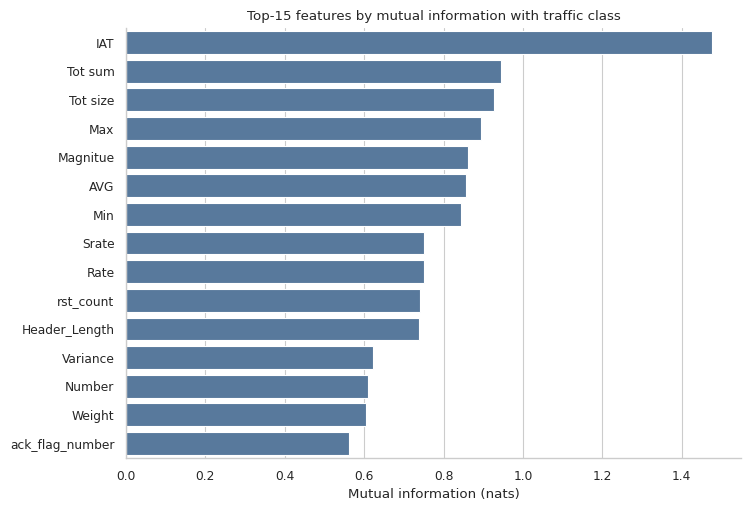

Bottom 8 (weakest class signal):


,feature,MI,rank,selected_k15
35,HTTP,0.0098,36,False
36,SSH,0.0085,37,False
37,Telnet,0.0062,38,False
38,IRC,0.0043,39,False
39,ece_flag_number,0.0000,40,False
40,cwr_flag_number,0.0000,41,False
41,SMTP,0.0000,42,False
42,IGMP,0.0000,43,False


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", context="paper")

num = X.select_dtypes(include=[np.number]).copy()
num = num.fillna(num.median(numeric_only=True))

y_enc = LabelEncoder().fit_transform(y)

mi = mutual_info_classif(
    num, y_enc,
    discrete_features=False,
    random_state=RANDOM_STATE,
    n_neighbors=3,
)
mi_rank = (
    pd.DataFrame({"feature": num.columns, "MI": mi})
      .sort_values("MI", ascending=False)
      .reset_index(drop=True)
)
mi_rank["rank"] = np.arange(1, len(mi_rank) + 1)
mi_rank["selected_k15"] = mi_rank["rank"] <= 15

mi_path = os.path.join(OUT_DIR, "mi_ranking_full_sample.csv")
mi_rank.to_csv(mi_path, index=False)
display(mi_rank.head(15).round(4))
print("Saved:", mi_path)

top = mi_rank.head(15)
fig, ax = plt.subplots(figsize=(7.6, 5.2))
sns.barplot(data=top, y="feature", x="MI", color="#4C78A8", ax=ax)
ax.set_title("Top-15 features by mutual information with traffic class")
ax.set_xlabel("Mutual information (nats)")
ax.set_ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

print("Bottom 8 (weakest class signal):")
display(mi_rank.tail(8).round(4))

**Figure. Mutual-information ranking.**
Higher bars are flow statistics that share more information with `{Benign, DDoS, DoS, MQTT, Recon, Spoofing}`. In CICIoMT2024 these are typically protocol indicators, selected TCP flags, and rate / inter-arrival features. Near-zero MI features are candidates to drop in Condition B.

This ranking is **not** the experimental subset. Condition A uses every remaining numeric feature. Condition B uses the 15 features with highest MI, re-estimated on the training portion of each fold so the test fold never chooses the subset.

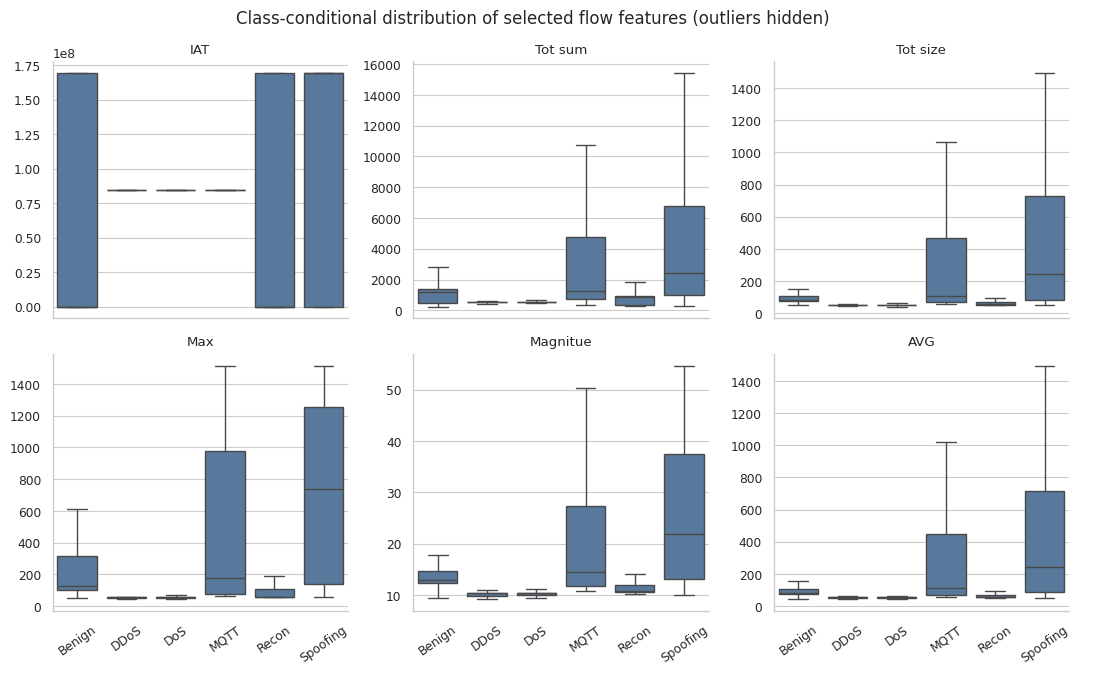

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

preferred = [
    "Protocol Type", "syn_flag_number", "ack_flag_number",
    "Rate", "Srate", "IAT", "Duration",
    "Header_Length", "fin_flag_number",
    "Magnitude", "Magnitue",   # CIC spelling variant
]
# if MI ranking exists, put those names first
if "mi_rank" in globals():
    preferred = list(mi_rank["feature"]) + preferred

seen, plot_feats = set(), []
for c in preferred:
    if c in df.columns and c not in seen:
        seen.add(c)
        plot_feats.append(c)
    if len(plot_feats) == 6:
        break

long = df[["label"] + plot_feats].melt(
    id_vars="label", var_name="feature", value_name="value"
)

g = sns.catplot(
    data=long,
    x="label",
    y="value",
    col="feature",
    col_wrap=3,
    kind="box",
    order=TARGET_CLASSES,
    sharey=False,
    showfliers=False,
    color="#4C78A8",
    height=3.2,
    aspect=1.15,
)
g.set_titles("{col_name}")
g.set_axis_labels("Traffic class", "")
g.fig.suptitle(
    "Class-conditional distribution of selected flow features (outliers hidden)",
    y=1.03, fontsize=12,
)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")
plt.show()

**Figure. Class-conditional boxplots.**
Each panel is one CIC flow statistic. The box is the interquartile range of that feature inside a traffic class; whiskers follow the usual 1.5-IQR rule. Extreme flood rates would crush the axis, so outliers are hidden. Separate *y*-scales are required because the features are not commensurate.

Read the panels as a sanity check, not as a model: SYN-flag mass should rise in SYN floods, protocol type should split ICMP/UDP/TCP families, and benign traffic should look less one-sided than a dedicated attack shard. Features that barely move across classes are consistent with a low mutual-information score and are weak candidates for the reduced subset.

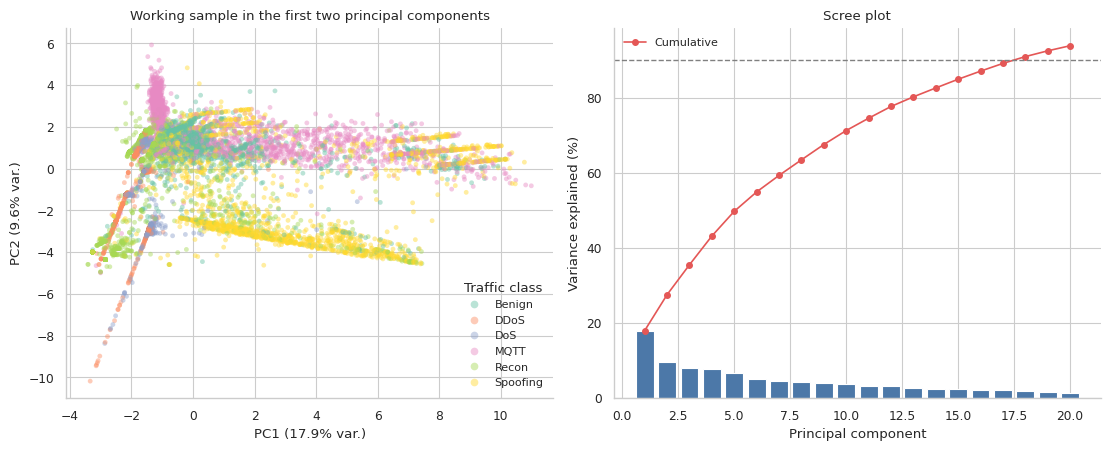

PC1+PC2 explain 27.5% of scaled variance.
Components needed for ≥90% variance: 18 / 43


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="paper")

num = X.select_dtypes(include=[np.number])
X_imp = num.fillna(num.median(numeric_only=True))
Z = StandardScaler().fit_transform(X_imp)

pca_full = PCA(random_state=RANDOM_STATE).fit(Z)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n90 = int(np.searchsorted(cum, 0.90) + 1)

pcs = pca_full.transform(Z)[:, :2]
pca_df = pd.DataFrame({
    "PC1": pcs[:, 0],
    "PC2": pcs[:, 1],
    "class": y.values,
})

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6))

sns.scatterplot(
    data=pca_df, x="PC1", y="PC2", hue="class", hue_order=TARGET_CLASSES,
    palette="Set2", s=12, alpha=0.45, linewidth=0, ax=axes[0],
)
axes[0].set_title("Working sample in the first two principal components")
axes[0].set_xlabel(f"PC1 ({100*evr[0]:.1f}% var.)")
axes[0].set_ylabel(f"PC2 ({100*evr[1]:.1f}% var.)")
axes[0].legend(title="Traffic class", fontsize=8, markerscale=1.6, frameon=False)

k = min(20, len(evr))
axes[1].bar(np.arange(1, k + 1), 100 * evr[:k], color="#4C78A8")
axes[1].plot(np.arange(1, k + 1), 100 * cum[:k], color="#E45756", marker="o",
             ms=4, label="Cumulative")
axes[1].axhline(90, color="grey", ls="--", lw=1)
axes[1].set_title("Scree plot")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Variance explained (%)")
axes[1].legend(frameon=False, fontsize=8)

sns.despine(fig)
plt.tight_layout()
plt.show()

print(f"PC1+PC2 explain {100*(evr[0]+evr[1]):.1f}% of scaled variance.")
print(f"Components needed for ≥90% variance: {n90} / {len(evr)}")

**Figure. Linear feature reduction (PCA).**
Left: each point is one flow from the cleaned working sample, projected onto the first two principal components of the *standardised* feature matrix. Colour is the 6-class label. Overlap is expected: DoS and DDoS floods share protocol structure, and two components are only a view.

Right: the scree plot shows how much variance successive components capture. If two components explain little of the total, a 2-D scatter cannot be used to claim that classes are (or are not) separable. The models in the next section still use the original features, or the mutual-information subset — not these PCs.

PCA here is descriptive geometry. It is not one of the four assigned classifiers.

/tmp/ipykernel_1063/1326301781.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(TSNE_N // tmp["label"].nunique(),


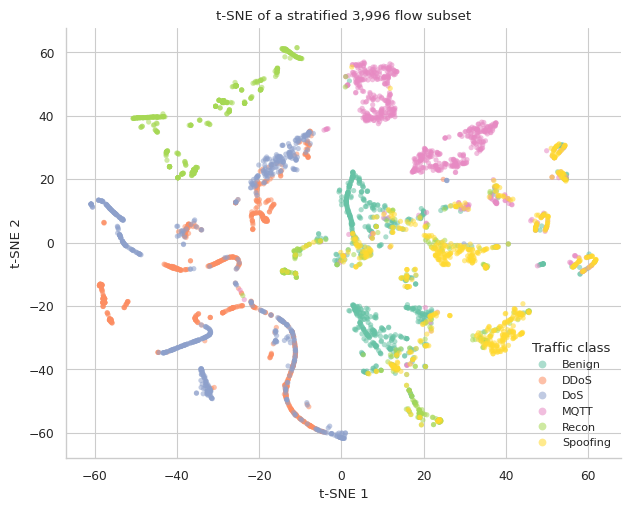

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid", context="paper")

# reuse scaled matrix if Section 3.6 already ran; otherwise rebuild
if "Z" not in globals() or "y" not in globals():
    num = X.select_dtypes(include=[np.number])
    Z = StandardScaler().fit_transform(num.fillna(num.median(numeric_only=True)))

TSNE_N = 4000
tsne_idx = (
    pd.Series(y)
      .groupby(y)
      .sample(n=min(TSNE_N // y.nunique(), y.value_counts().min()),
              random_state=RANDOM_STATE)
      .index
)

Z_sub = Z[tsne_idx] if isinstance(Z, np.ndarray) else Z.iloc[tsne_idx]
# Z is ndarray from StandardScaler → index with positions
if isinstance(tsne_idx, pd.Index):
    pos = df.loc[tsne_idx].index.get_indexer_for(tsne_idx)
    # safer: sample by position from a reset frame
tmp = pd.DataFrame(Z)
tmp["label"] = y.values
sub = (
    tmp.groupby("label", group_keys=False)
       .apply(lambda g: g.sample(n=min(TSNE_N // tmp["label"].nunique(),
                                       len(g)),
                                 random_state=RANDOM_STATE))
)
Z_sub = sub.drop(columns="label").to_numpy()
y_sub = sub["label"].to_numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=750,
    random_state=RANDOM_STATE,
)
emb = tsne.fit_transform(Z_sub)

tsne_df = pd.DataFrame({"TSNE1": emb[:, 0], "TSNE2": emb[:, 1], "class": y_sub})

fig, ax = plt.subplots(figsize=(6.4, 5.2))
sns.scatterplot(
    data=tsne_df, x="TSNE1", y="TSNE2",
    hue="class", hue_order=TARGET_CLASSES,
    palette="Set2", s=14, alpha=0.55, linewidth=0, ax=ax,
)
ax.set_title(f"t-SNE of a stratified {len(tsne_df):,} flow subset")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(title="Traffic class", fontsize=8, markerscale=1.5, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

**Figure. t-SNE snapshot.**
Points are a stratified subset of the cleaned working sample, mapped with t-SNE (`perplexity=30`, PCA initialisation). Colour is the 6-class label. Tight clusters mean that *local* neighbourhoods in the scaled feature space often share a class; they do not mean that the four assigned models will separate every class.

t-SNE does not preserve global distances, is sensitive to perplexity, and is not used as input to LR, k-NN, Decision Tree or SVM. Together with PCA it only supports a qualitative claim: the 45 flow statistics contain class structure, with more overlap between related flood families than between flood and reconnaissance traffic.

## 4. Experimental setup

All models are trained on the cleaned working table. The comparative factor is the feature set.

- **Condition A** — every numeric feature that survived constant-feature removal.
- **Condition B** — the 15 features with highest mutual information with the 6-class label. The selector sits *inside* the pipeline so each training fold chooses its own subset.

**Protocol.** Stratified 80/20 hold-out (`random_state=42`). Hyper-parameters are chosen by stratified 5-fold CV on the 80% training block. Median imputation and standardisation are fitted on training folds only.

**Learners.** Logistic regression, *k*-NN, decision tree, RBF-SVM. Macro-F1 is the primary score. The hold-out test set is not used for selection.

In [26]:
# Section 4 — experimental setup (no fitting)
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

assert "OUT_DIR" in globals(), "Run Cell 0 first."

clean_path = os.path.join(OUT_DIR, "ciciomt2024_6class_clean.csv")
df = pd.read_csv(clean_path)

y = df["label"]
X = (
    df.drop(columns=[c for c in ("label", "source_file") if c in df.columns])
      .select_dtypes(include=[np.number])
)

print("Matrix:", X.shape, "| classes:", y.nunique())
print(y.value_counts().reindex(TARGET_CLASSES))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
K_MI = 15

MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE,
    ),
    "k-NN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
}

PARAM_GRIDS = {
    "Logistic Regression": {"clf__C": [0.1, 1, 10]},
    "k-NN": {"clf__n_neighbors": [3, 5, 11]},
    "Decision Tree": {
        "clf__max_depth": [5, 10, None],
        "clf__min_samples_leaf": [1, 5],
    },
    "SVM": {
        "clf__C": [1, 10],
        "clf__gamma": ["scale", 0.01],
    },
}


def make_pipe(estimator, use_mi=False, k=K_MI):
    steps = [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
    if use_mi:
        steps.append((
            "select",
            SelectKBest(score_func=mutual_info_classif, k=min(k, X.shape[1])),
        ))
    steps.append(("clf", estimator))
    return Pipeline(steps)


design = pd.DataFrame([
    {
        "condition": cond,
        "features": "all numeric" if cond == "A" else f"MI top-{K_MI} (train-fold)",
        "model": name,
        "n_params": int(np.prod([len(v) for v in PARAM_GRIDS[name].values()])),
    }
    for cond in ["A", "B"]
    for name in MODELS
])
display(design)
print("CV folds:", cv.get_n_splits(), "| seed:", RANDOM_STATE)
print("Setup ready. Next section fits the eight pipelines.")

Matrix: (11989, 43) | classes: 6
label
Benign      2000
DDoS        2000
DoS         2000
MQTT        2000
Recon       1989
Spoofing    2000
Name: count, dtype: int64
Train: (9591, 43) | Test: (2398, 43)


,condition,features,model,n_params
0,A,all numeric,Logistic Regression,3
1,A,all numeric,k-NN,3
2,A,all numeric,Decision Tree,6
3,A,all numeric,SVM,4
4,B,MI top-15 (train-fold),Logistic Regression,3
5,B,MI top-15 (train-fold),k-NN,3
6,B,MI top-15 (train-fold),Decision Tree,6
7,B,MI top-15 (train-fold),SVM,4


CV folds: 5 | seed: 42
Setup ready. Next section fits the eight pipelines.


In [27]:
# Section 5 — fit the 8 pipelines
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)

rows, fitted = [], {}

for cond in ["A", "B"]:
    use_mi = cond == "B"
    for name, base_clf in MODELS.items():
        pipe = make_pipe(clone(base_clf), use_mi=use_mi)
        gs = GridSearchCV(
            pipe,
            PARAM_GRIDS[name],
            scoring="f1_macro",
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        print(f"Fitting {name} | Condition {cond} ...")
        gs.fit(X_train, y_train)

        y_pred = gs.predict(X_test)
        rec = {
            "condition": cond,
            "model": name,
            "best_params": gs.best_params_,
            "cv_macro_f1": gs.best_score_,
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_macro_f1": f1_score(y_test, y_pred, average="macro"),
            "test_weighted_f1": f1_score(y_test, y_pred, average="weighted"),
            "test_macro_precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "test_macro_recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        }
        rows.append(rec)
        fitted[(cond, name)] = {"search": gs, "y_pred": y_pred}
        print(f"  CV macro-F1={rec['cv_macro_f1']:.3f}  "
              f"test macro-F1={rec['test_macro_f1']:.3f}  "
              f"{rec['best_params']}")

results = (
    pd.DataFrame(rows)
      .sort_values(["model", "condition"])
      .reset_index(drop=True)
)
res_path = os.path.join(OUT_DIR, "model_comparison.csv")
results.to_csv(res_path, index=False)
print("\nSaved:", res_path)
display(results.drop(columns="best_params"))
display(results[["condition", "model", "best_params"]])

Fitting Logistic Regression | Condition A ...
  CV macro-F1=0.763  test macro-F1=0.770  {'clf__C': 10}
Fitting k-NN | Condition A ...
  CV macro-F1=0.847  test macro-F1=0.857  {'clf__n_neighbors': 5}
Fitting Decision Tree | Condition A ...
  CV macro-F1=0.946  test macro-F1=0.948  {'clf__max_depth': None, 'clf__min_samples_leaf': 1}
Fitting SVM | Condition A ...
  CV macro-F1=0.788  test macro-F1=0.788  {'clf__C': 10, 'clf__gamma': 'scale'}
Fitting Logistic Regression | Condition B ...
  CV macro-F1=0.611  test macro-F1=0.631  {'clf__C': 10}
Fitting k-NN | Condition B ...
  CV macro-F1=0.828  test macro-F1=0.836  {'clf__n_neighbors': 11}
Fitting Decision Tree | Condition B ...
  CV macro-F1=0.944  test macro-F1=0.948  {'clf__max_depth': 10, 'clf__min_samples_leaf': 1}
Fitting SVM | Condition B ...
  CV macro-F1=0.756  test macro-F1=0.758  {'clf__C': 10, 'clf__gamma': 'scale'}

Saved: /content/drive/MyDrive/3.ML Project MBUST/dataset/results/model_comparison.csv


,condition,model,cv_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,test_macro_precision,test_macro_recall
0,A,Decision Tree,0.945858,0.948290,0.948258,0.948274,0.948321,0.948281
1,B,Decision Tree,0.943615,0.947456,0.947996,0.948014,0.949869,0.947416
2,A,Logistic Regression,0.762858,0.768974,0.770035,0.769955,0.774288,0.769028
3,B,Logistic Regression,0.610526,0.642202,0.631472,0.631481,0.672330,0.642190
4,A,SVM,0.787840,0.787740,0.788373,0.788282,0.800959,0.787812
5,B,SVM,0.755913,0.765638,0.757961,0.757882,0.796175,0.765693
6,A,k-NN,0.846794,0.856964,0.857470,0.857444,0.858696,0.856985
7,B,k-NN,0.827589,0.834862,0.836167,0.836144,0.840956,0.834883


,condition,model,best_params
0,A,Decision Tree,"{'clf__max_depth': None, 'clf__min_samples_lea..."
1,B,Decision Tree,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
2,A,Logistic Regression,{'clf__C': 10}
3,B,Logistic Regression,{'clf__C': 10}
4,A,SVM,"{'clf__C': 10, 'clf__gamma': 'scale'}"
5,B,SVM,"{'clf__C': 10, 'clf__gamma': 'scale'}"
6,A,k-NN,{'clf__n_neighbors': 5}
7,B,k-NN,{'clf__n_neighbors': 11}


## 6. Comparative result: full features vs MI top-15

Test macro-F1 for each learner under Condition A (all features) and Condition B (mutual-information subset selected inside the training pipe). The height difference is the cost, or gain, of using 15 features instead of the full set.

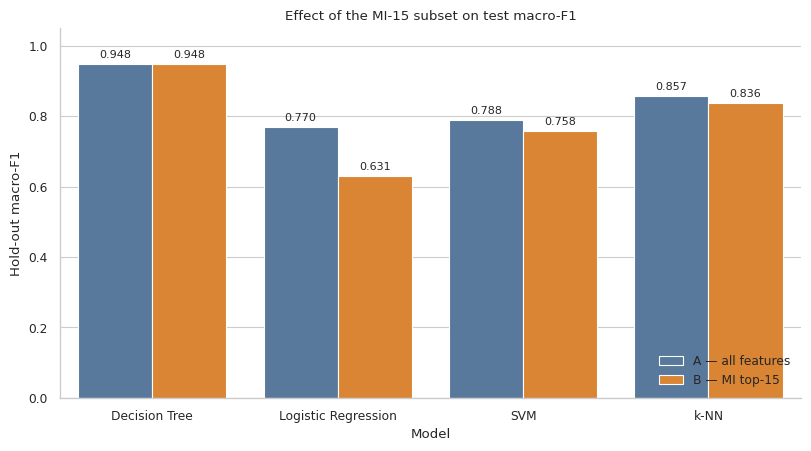

condition,macro_f1_A,macro_f1_B,delta_B_minus_A,abs_delta
model,,,,
Decision Tree,0.9483,0.9480,-0.0003,0.0003
k-NN,0.8575,0.8362,-0.0213,0.0213
SVM,0.7884,0.7580,-0.0304,0.0304
Logistic Regression,0.7700,0.6315,-0.1386,0.1386


Saved figure: /content/drive/MyDrive/3.ML Project MBUST/dataset/results/fig_macro_f1_A_vs_B.png


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

plot_df = results[["condition", "model", "test_macro_f1"]].copy()
plot_df["condition"] = plot_df["condition"].map({
    "A": "A — all features",
    "B": "B — MI top-15",
})

fig, ax = plt.subplots(figsize=(8.2, 4.6))
sns.barplot(
    data=plot_df,
    x="model",
    y="test_macro_f1",
    hue="condition",
    palette=["#4C78A8", "#F58518"],
    ax=ax,
)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model")
ax.set_ylabel("Hold-out macro-F1")
ax.set_title("Effect of the MI-15 subset on test macro-F1")
ax.legend(title="", frameon=False, loc="lower right")

# value labels
for p in ax.patches:
    h = p.get_height()
    if np.isfinite(h) and h > 0:
        ax.annotate(f"{h:.3f}",
                    (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 3), textcoords="offset points")

sns.despine()
plt.tight_layout()
plt.show()

# signed change B − A (negative = subset costs performance)
wide = (
    results.pivot(index="model", columns="condition", values="test_macro_f1")
           .rename(columns={"A": "macro_f1_A", "B": "macro_f1_B"})
)
wide["delta_B_minus_A"] = wide["macro_f1_B"] - wide["macro_f1_A"]
wide["abs_delta"] = wide["delta_B_minus_A"].abs()
wide = wide.round(4)
display(wide.sort_values("macro_f1_A", ascending=False))

fig_path = os.path.join(OUT_DIR, "fig_macro_f1_A_vs_B.png")
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
wide.to_csv(os.path.join(OUT_DIR, "delta_macro_f1.csv"))
print("Saved figure:", fig_path)

**Figure. Comparative study.**
Each pair of bars is one assigned classifier. Blue is the full numeric feature set; orange is the 15-feature MI subset. A small orange deficit means the compact subset is sufficient for that learner. A large deficit means that learner was using information that MI, being univariate, discarded.

The table reports $\Delta = \mathrm{F1}_B - \mathrm{F1}_A$ on the same hold-out split. We treat $|\Delta| < 0.02$ as practically equivalent for this assignment.

## 7. Per-class F1 on the hold-out set

Macro-F1 averages six labels. This table splits that average so we can see which traffic class each model actually gets right under both feature conditions. DoS vs DDoS and the smaller recon/spoofing tails are the usual failure modes on CICIoMT2024.

class                          Benign   DDoS    DoS   MQTT  Recon  Spoofing
model               condition                                              
Decision Tree       A           0.919  1.000  0.995  0.955  0.929     0.892
                    B           0.931  0.999  0.999  0.958  0.926     0.875
Logistic Regression A           0.837  0.681  0.637  0.875  0.866     0.725
                    B           0.847  0.652  0.357  0.641  0.620     0.671
SVM                 A           0.880  0.676  0.586  0.905  0.897     0.786
                    B           0.871  0.705  0.478  0.887  0.852     0.755
k-NN                A           0.840  0.881  0.875  0.885  0.889     0.775
                    B           0.851  0.835  0.820  0.887  0.864     0.761

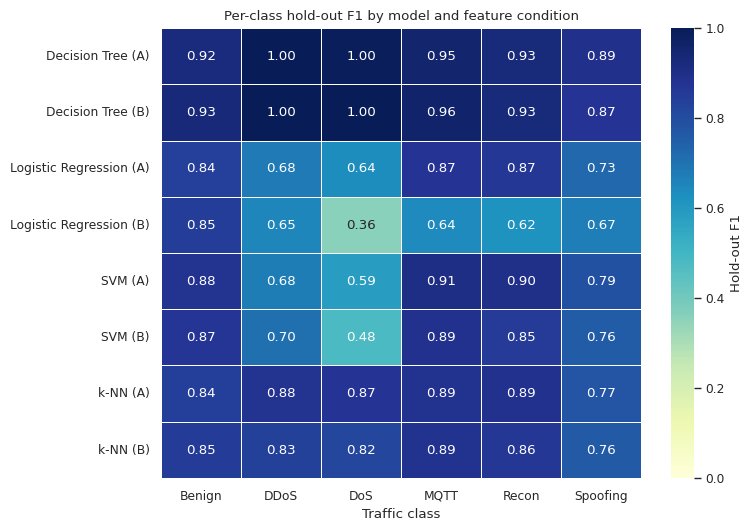

,model,condition,weakest_class,weakest_f1
0,Decision Tree,A,Spoofing,0.892
1,Decision Tree,B,Spoofing,0.875
2,Logistic Regression,A,DoS,0.637
3,Logistic Regression,B,DoS,0.357
4,SVM,A,DoS,0.586
5,SVM,B,DoS,0.478
6,k-NN,A,Spoofing,0.775
7,k-NN,B,Spoofing,0.761


In [29]:
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

per_class_rows = []
for (cond, name), pack in fitted.items():
    f1s = f1_score(
        y_test, pack["y_pred"],
        labels=TARGET_CLASSES,
        average=None,
        zero_division=0,
    )
    for cls, f1 in zip(TARGET_CLASSES, f1s):
        per_class_rows.append({
            "condition": cond,
            "model": name,
            "class": cls,
            "f1": f1,
        })

per_class = pd.DataFrame(per_class_rows)
table = (
    per_class.pivot_table(
        index=["model", "condition"],
        columns="class",
        values="f1",
    )
    .reindex(columns=TARGET_CLASSES)
    .round(3)
)
display(table)
table.to_csv(os.path.join(OUT_DIR, "per_class_f1.csv"))

# heatmap: models stacked A then B
heat = (
    per_class.assign(row=lambda d: d["model"] + " (" + d["condition"] + ")")
             .pivot(index="row", columns="class", values="f1")
             .reindex(columns=TARGET_CLASSES)
)

fig, ax = plt.subplots(figsize=(7.8, 5.4))
sns.heatmap(
    heat, vmin=0, vmax=1, cmap="YlGnBu", annot=True, fmt=".2f",
    linewidths=0.4, ax=ax, cbar_kws={"label": "Hold-out F1"},
)
ax.set_title("Per-class hold-out F1 by model and feature condition")
ax.set_xlabel("Traffic class")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(OUT_DIR, "fig_per_class_f1.png"),
            dpi=200, bbox_inches="tight")

# weakest class per experiment
weak = (
    per_class.sort_values("f1")
             .groupby(["model", "condition"], as_index=False)
             .first()
             .rename(columns={"class": "weakest_class", "f1": "weakest_f1"})
)
display(weak.round(3))

**Table / figure. Class-wise F1.**
Each cell is F1 for one traffic class on the untouched 20% test split. Read down a column to see whether Condition B hurts a particular class; read across a row to see which class limits that model.

A dark column (high F1) for MQTT or Benign with a pale column for DoS or DDoS means the model can detect “an attack family exists” but cannot separate single-source from distributed floods. That confusion is expected from the feature design: both families share protocol and flag structure and differ mainly in volume, which our per-class cap partly removed.

## 8. Hold-out confusion matrices

Rows are true traffic classes; columns are predictions. Matrices use the same class order as the rest of the notebook. Off-diagonal mass between DoS and DDoS is the main error we expect; off-diagonal mass involving Recon or Spoofing is the second place to look.

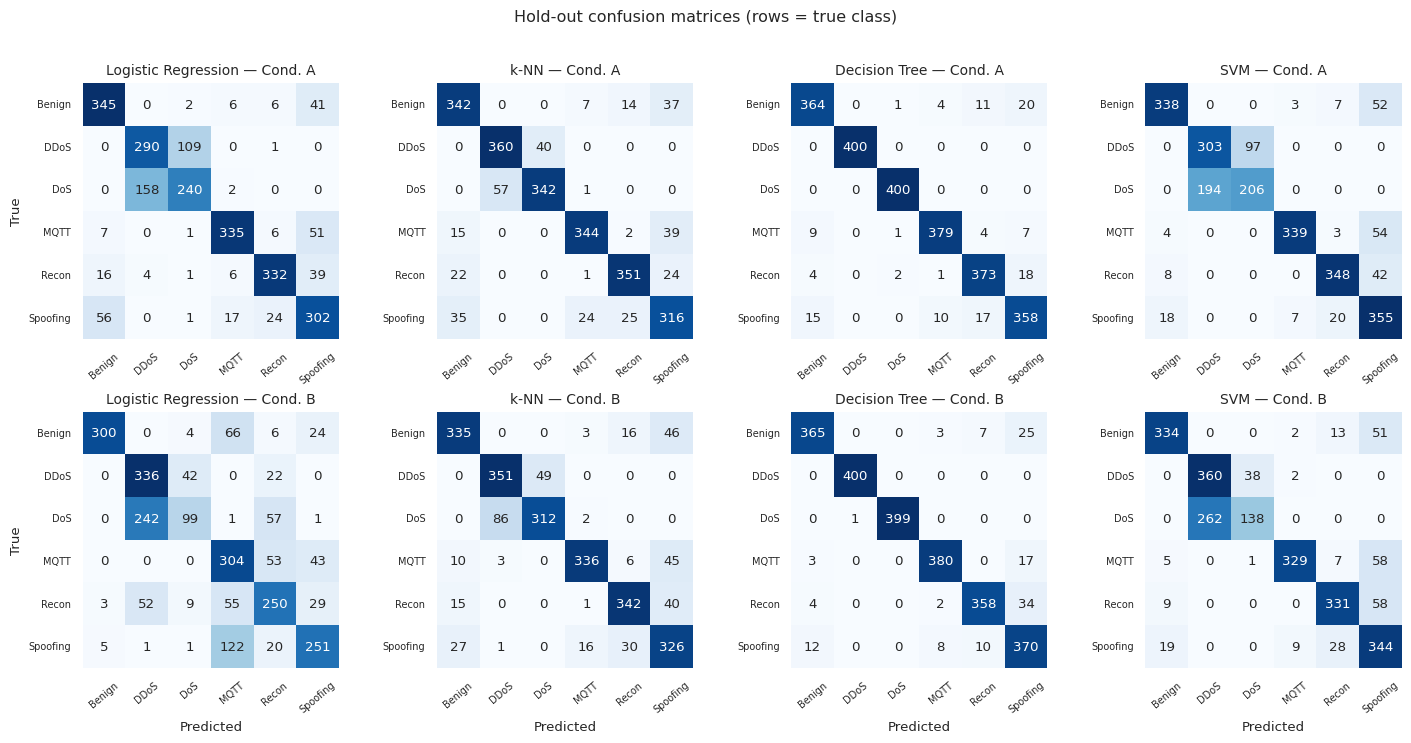

,condition,model,DoS_to_DDoS,DDoS_to_DoS
0,A,Logistic Regression,0.395,0.272
1,A,k-NN,0.142,0.100
2,A,Decision Tree,0.000,0.000
3,A,SVM,0.485,0.242
4,B,Logistic Regression,0.605,0.105
5,B,k-NN,0.215,0.122
6,B,Decision Tree,0.002,0.000
7,B,SVM,0.655,0.095


In [30]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")

models = list(MODELS.keys())
fig, axes = plt.subplots(2, 4, figsize=(14.5, 7.2))

for i, cond in enumerate(["A", "B"]):
    for j, name in enumerate(models):
        ax = axes[i, j]
        y_pred = fitted[(cond, name)]["y_pred"]
        cm = confusion_matrix(y_test, y_pred, labels=TARGET_CLASSES)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES,
            ax=ax, square=True,
        )
        ax.set_title(f"{name} — Cond. {cond}", fontsize=10)
        ax.set_xlabel("Predicted" if i == 1 else "")
        ax.set_ylabel("True" if j == 0 else "")
        ax.tick_params(axis="x", labelrotation=40, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Hold-out confusion matrices (rows = true class)", y=1.02)
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(OUT_DIR, "fig_confusion_matrices.png"),
            dpi=200, bbox_inches="tight")

# pairwise confusion rates for the two flood families
pairs = []
for cond in ["A", "B"]:
    for name in models:
        y_pred = pd.Series(fitted[(cond, name)]["y_pred"], index=y_test.index)
        n_dos = int(y_test.eq("DoS").sum())
        n_ddos = int(y_test.eq("DDoS").sum())
        pairs.append({
            "condition": cond,
            "model": name,
            "DoS_to_DDoS": (y_test.eq("DoS") & y_pred.eq("DDoS")).sum() / max(n_dos, 1),
            "DDoS_to_DoS": (y_test.eq("DDoS") & y_pred.eq("DoS")).sum() / max(n_ddos, 1),
        })
leak = pd.DataFrame(pairs).round(3)
display(leak)
leak.to_csv(os.path.join(OUT_DIR, "dos_ddos_leakage.csv"), index=False)

**Figure. Confusion matrices.**
Compare the DoS row/column with the DDoS row/column first. Those two classes are generated from the same flood mechanisms and differ mainly in source multiplicity; after a per-class cap they look alike in flow statistics, so leakage between them is a dataset property rather than a broken implementation.

Then compare Condition A with B for the same model. If the off-diagonal pattern is unchanged, the MI subset discarded redundant features rather than discriminative ones. If a rare class (Spoofing, Recon) collapses only under B, univariate MI under-ranked an interaction that the full set was using.

The small table reports the fraction of true DoS predicted as DDoS and the reverse. Those two numbers belong in the discussion, next to the macro-F1 deltas.

## 9. Features selected under Condition B

`SelectKBest` is refit on the full training block when `GridSearchCV` refits the winner. We read that support mask for each Condition-B pipeline and compare it with the descriptive MI ranking from Section 3.5. Agreement means the subset is stable; disagreement is why the subset must be chosen inside the pipe rather than frozen from EDA.

In [31]:
import numpy as np
import pandas as pd

assert "mi_rank" in globals(), "Run the Section 3.5 MI cell first (or load the CSV)."

if "mi_rank" not in globals():
    mi_rank = pd.read_csv(os.path.join(OUT_DIR, "mi_ranking_full_sample.csv"))

eda_top15 = set(mi_rank.sort_values("MI", ascending=False).head(15)["feature"])

sel_rows = []
for name in MODELS:
    pipe = fitted[("B", name)]["search"].best_estimator_
    selector = pipe.named_steps["select"]
    chosen = list(X_train.columns[selector.get_support()])
    for r, feat in enumerate(chosen, start=1):
        sel_rows.append({
            "model": name,
            "feature": feat,
            "in_eda_top15": feat in eda_top15,
        })
    print(f"\n{name} (Condition B) — {len(chosen)} features")
    print(" ", ", ".join(chosen))

selected = pd.DataFrame(sel_rows)
overlap = (
    selected.groupby("model")["in_eda_top15"]
            .mean()
            .mul(15)
            .rename("n_overlap_with_eda_top15")
            .round(1)
)
display(overlap.to_frame())

# how often each feature is chosen across the four B pipelines
freq = (
    selected.groupby("feature")
            .size()
            .rename("n_models")
            .sort_values(ascending=False)
            .reset_index()
)
freq["in_eda_top15"] = freq["feature"].isin(eda_top15)
display(freq)
freq.to_csv(os.path.join(OUT_DIR, "condition_B_selected_features.csv"), index=False)

print("\nEDA top-15:")
print(", ".join(mi_rank.sort_values("MI", ascending=False).head(15)["feature"]))


Logistic Regression (Condition B) — 15 features
  Header_Length, Rate, Srate, ack_flag_number, rst_count, Tot sum, Min, Max, AVG, Tot size, IAT, Number, Magnitue, Variance, Weight

k-NN (Condition B) — 15 features
  Header_Length, Rate, Srate, psh_flag_number, rst_count, Tot sum, Min, Max, AVG, Tot size, IAT, Number, Magnitue, Variance, Weight

Decision Tree (Condition B) — 15 features
  Header_Length, Rate, Srate, psh_flag_number, rst_count, Tot sum, Min, Max, AVG, Tot size, IAT, Number, Magnitue, Variance, Weight

SVM (Condition B) — 15 features
  Header_Length, Rate, Srate, ack_flag_number, rst_count, Tot sum, Min, Max, AVG, Tot size, IAT, Number, Magnitue, Variance, Weight


,n_overlap_with_eda_top15
model,
Decision Tree,14.0
Logistic Regression,15.0
SVM,15.0
k-NN,14.0


,feature,n_models,in_eda_top15
0,AVG,4,True
1,Header_Length,4,True
2,IAT,4,True
3,Magnitue,4,True
4,Max,4,True
5,Min,4,True
6,Number,4,True
7,Rate,4,True
8,Srate,4,True
9,Tot size,4,True



EDA top-15:
IAT, Tot sum, Tot size, Max, Magnitue, AVG, Min, Srate, Rate, rst_count, Header_Length, Variance, Number, Weight, ack_flag_number


**Table. Condition-B subset vs EDA ranking.**
`n_overlap_with_eda_top15` is how many of the 15 training-set features also appear in the full-sample MI list. `n_models` is how many of the four Condition-B pipes selected that feature (maximum 4). Features chosen by every model are the stable core of the compact representation; features chosen by one model only are selector noise and should not be over-interpreted.

If overlap is 12–15, the EDA figure and the experiment tell the same story. If overlap is much lower, keep the experimental subset (training-fold MI) as the official Condition B and treat the EDA bar chart as descriptive only.

## 10. Which features do the fitted models actually use?

Condition B ranks features by *univariate* mutual information. That need not be what a fitted classifier uses.

We therefore compute **permutation importance** on the hold-out set for each Condition-A pipeline: the drop in macro-F1 when a column is shuffled. This is model-agnostic and does not refit.

For the decision tree we also report TreeSHAP mean |value| as a local-explanation check. SVM and k-NN are not explained with KernelSHAP here (cost).

Agreement between permutation ranks, TreeSHAP, and the MI-15 list supports the subset experiment. Disagreement means MI discarded interactions that a particular model needs — which should match any large A→B drop for that model.

Permutation importance: Logistic Regression
Permutation importance: k-NN
Permutation importance: Decision Tree
Permutation importance: SVM


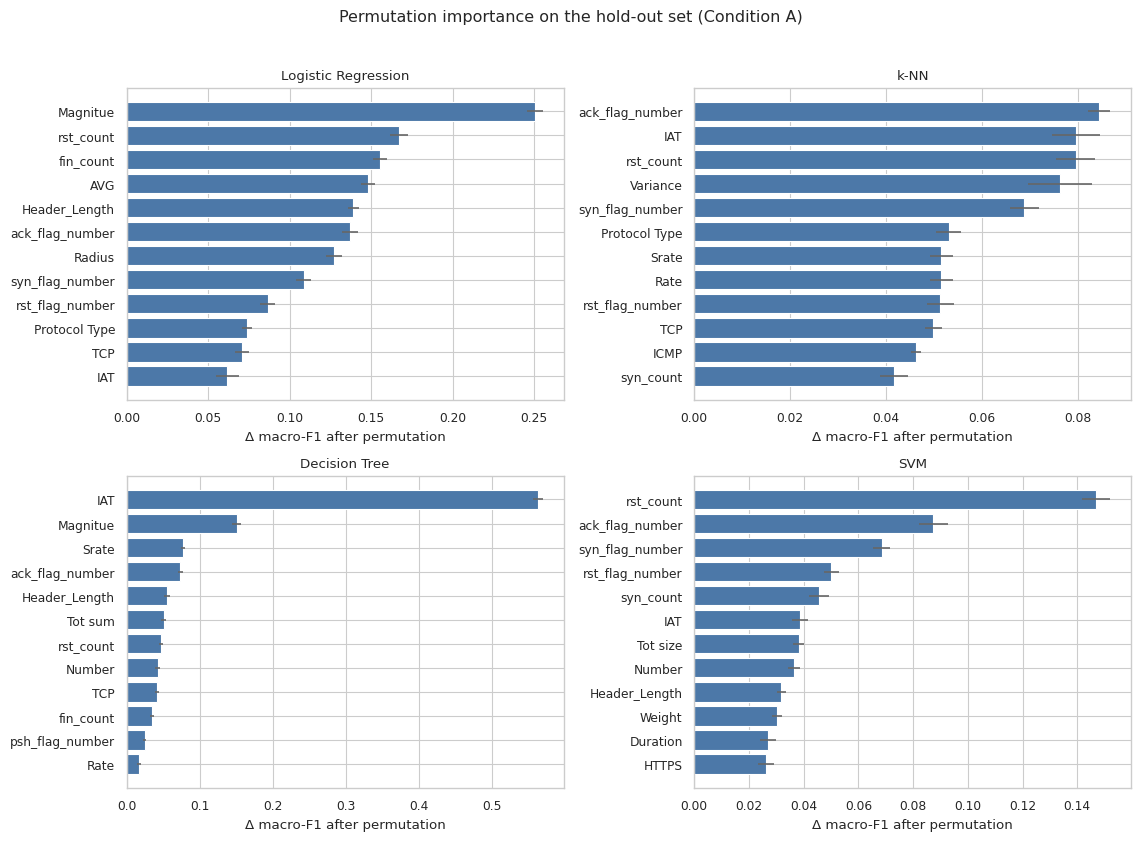

,model,overlap_with_MI15,only_in_model
0,Logistic Regression,7,"Covariance, Protocol Type, Radius, TCP, fin_co..."
1,k-NN,8,"ICMP, Protocol Type, TCP, UDP, rst_flag_number..."
2,Decision Tree,11,"TCP, fin_count, psh_flag_number, syn_count"
3,SVM,8,"Duration, HTTPS, ICMP, fin_count, rst_flag_num..."


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", context="paper")

N_REPEAT = 8
imp_rows = []

for name in MODELS:
    pipe = fitted[("A", name)]["search"].best_estimator_
    print("Permutation importance:", name)
    r = permutation_importance(
        pipe, X_test, y_test,
        scoring="f1_macro",
        n_repeats=N_REPEAT,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    imp_rows.append(pd.DataFrame({
        "model": name,
        "feature": X_test.columns,
        "importance": r.importances_mean,
        "std": r.importances_std,
    }))

imp = pd.concat(imp_rows, ignore_index=True)
imp.to_csv(os.path.join(OUT_DIR, "permutation_importance_A.csv"), index=False)

top_k = 12
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.2), sharex=False)
for ax, name in zip(axes.ravel(), MODELS):
    part = (imp.loc[imp["model"] == name]
               .nlargest(top_k, "importance")
               .sort_values("importance"))
    ax.barh(part["feature"], part["importance"], xerr=part["std"],
            color="#4C78A8", ecolor="0.4")
    ax.set_title(name)
    ax.set_xlabel("Δ macro-F1 after permutation")
fig.suptitle("Permutation importance on the hold-out set (Condition A)", y=1.02)
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(OUT_DIR, "fig_permutation_importance.png"),
            dpi=200, bbox_inches="tight")

# overlap of each model's top-15 perm. features with EDA MI-15
eda_top15 = set(mi_rank.sort_values("MI", ascending=False).head(15)["feature"])
ov = []
for name in MODELS:
    top = set(imp.loc[imp["model"] == name].nlargest(15, "importance")["feature"])
    ov.append({
        "model": name,
        "overlap_with_MI15": len(top & eda_top15),
        "only_in_model": ", ".join(sorted(top - eda_top15)[:8]),
    })
display(pd.DataFrame(ov))

n features: 43 | SHAP vector: (43,)


,feature,mean_abs_shap
0,IAT,0.1456
1,Magnitue,0.0962
2,Srate,0.0404
3,Header_Length,0.0268
4,rst_count,0.0255
5,ack_flag_number,0.0159
6,Number,0.0158
7,Tot sum,0.0151
8,TCP,0.0126
9,Variance,0.0058


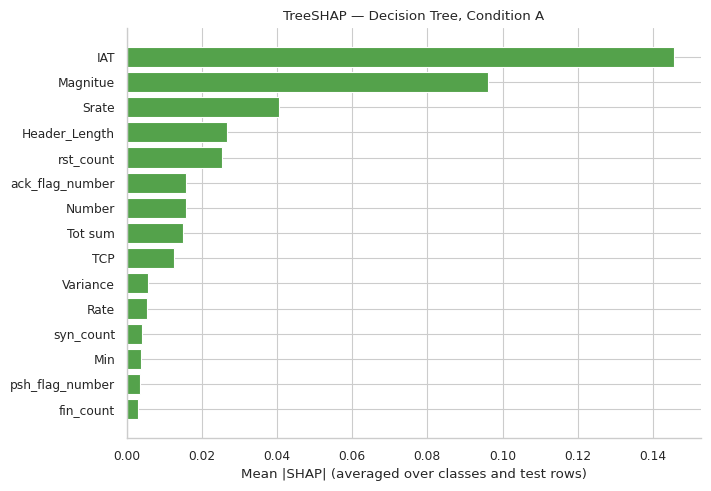

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tree_pipe = fitted[("A", "Decision Tree")]["search"].best_estimator_
clf = tree_pipe.named_steps["clf"]
feat_names = list(X_test.columns)

X_test_t = tree_pipe[:-1].transform(X_test)
# some sklearn versions return a DataFrame
X_test_t = np.asarray(X_test_t)

explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(X_test_t)

def mean_abs_shap(sv, n_features):
    """Return a vector of length n_features."""
    if isinstance(sv, list):                       # one (n, p) array per class
        arr = np.stack([np.abs(a) for a in sv], axis=-1)   # (n, p, C)
    else:
        arr = np.abs(np.asarray(getattr(sv, "values", sv)))
        # possible layouts: (n, p), (n, p, C), (n, C, p)
        if arr.ndim == 2:
            arr = arr[:, :, None]
        elif arr.ndim == 3 and arr.shape[1] != n_features and arr.shape[2] == n_features:
            arr = np.transpose(arr, (0, 2, 1))     # (n, C, p) → (n, p, C)
    if arr.shape[1] != n_features:
        raise ValueError(f"SHAP axis mismatch: {arr.shape} vs n_features={n_features}")
    return arr.mean(axis=(0, 2))                   # mean over samples and classes

mean_abs = mean_abs_shap(sv, n_features=len(feat_names))
print("n features:", len(feat_names), "| SHAP vector:", mean_abs.shape)

shap_rank = (
    pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs})
      .sort_values("mean_abs_shap", ascending=False)
      .reset_index(drop=True)
)
display(shap_rank.head(15).round(4))
shap_rank.to_csv(os.path.join(OUT_DIR, "treeshap_decision_tree_A.csv"), index=False)

fig, ax = plt.subplots(figsize=(7.2, 5.0))
top = shap_rank.head(15).iloc[::-1]
ax.barh(top["feature"], top["mean_abs_shap"], color="#54A24B")
ax.set_xlabel("Mean |SHAP| (averaged over classes and test rows)")
ax.set_title("TreeSHAP — Decision Tree, Condition A")
sns.despine()
plt.tight_layout()
plt.show()